In [1]:
from baselines.Custom import ippo_ff_mpe, ippo_rnn_mpe, mappo_rnn_mpe
from baselines.Custom.simple_spread_visualizer import MPEVisualizer
import importlib.resources as resources
import yaml
from omegaconf import OmegaConf
import os
os.environ["WANDB_NOTEBOOK_NAME"] = "Playground.ipynb"

from IPython.display import HTML, display


import jax
import jax.numpy as jnp
import flax
import numpy as np
from matplotlib import animation
from IPython.display import HTML, display
import jaxmarl
from jaxmarl.environments.mpe.simple_spread import SimpleSpreadMPE
from jaxmarl.wrappers.baselines import MPELogWrapper
from baselines.Custom.ippo_rnn_mpe import ActorCriticRNN, ScannedRNN 



In [2]:
import jax
import jaxlib
import flax

print(jax.devices())
print("JAX version:", jax.__version__)
print("JAXlib version:", jaxlib.__version__)
print("Flax version:", flax.__version__)


[CudaDevice(id=0)]
JAX version: 0.4.38
JAXlib version: 0.4.38
Flax version: 0.10.1


In [3]:
algo_and_config_map = {
    "ippo_ff_mpe": (ippo_ff_mpe, OmegaConf.load(resources.files("baselines.Custom.config") / "ippo_ff_mpe_simple_spread.yaml")),
    "ippo_rnn_mpe": (ippo_rnn_mpe, OmegaConf.load(resources.files("baselines.Custom.config") / "ippo_rnn_mpe_simple_spread.yaml")),
    "mappo_rnn_mpe": (mappo_rnn_mpe, OmegaConf.load(resources.files("baselines.Custom.config") / "mappo_homogenous_rnn_mpe_simple_spread.yaml"))
}

In [4]:
%%time
ALGO_NAME = "ippo_rnn_mpe"
algo, config = algo_and_config_map[ALGO_NAME]

CPU times: user 37 μs, sys: 0 ns, total: 37 μs
Wall time: 42.2 μs


In [5]:
%%time
ALGO_NAME = "ippo_rnn_mpe"
algo, config = algo_and_config_map[ALGO_NAME]
config['TOTAL_TIMESTEPS'] = 100
config["ENV_KWARGS"] = {}

CPU times: user 245 μs, sys: 176 μs, total: 421 μs
Wall time: 451 μs


In [6]:
config

{'ENV_NAME': 'MPE_simple_spread_v3', 'LR': 0.0005, 'NUM_ENVS': 16, 'NUM_STEPS': 128, 'FC_DIM_SIZE': 128, 'GRU_HIDDEN_DIM': 128, 'TOTAL_TIMESTEPS': 100, 'UPDATE_EPOCHS': 4, 'NUM_MINIBATCHES': 2, 'GAMMA': 0.99, 'GAE_LAMBDA': 0.95, 'CLIP_EPS': 0.3, 'SCALE_CLIP_EPS': False, 'ENT_COEF': 0.01, 'VF_COEF': 1.0, 'MAX_GRAD_NORM': 0.5, 'ACTIVATION': 'tanh', 'ANNEAL_LR': True, 'SEED': 30, 'ENTITY': 'dbraga14-princeton-university', 'PROJECT': 'scaling', 'WANDB_MODE': 'offline', 'RUN_NAME': 'ippo-rnn-simple-spread', 'ENV_KWARGS': {}}

In [7]:
import time
for num_agents in range(4,5):
    for num_landmarks in range(4,5):
        start = time.time()
        config["ENV_KWARGS"]["num_agents"] = num_agents
        config["ENV_KWARGS"]["num_landmarks"] = num_landmarks
        config['RUN_NAME'] = f"ippo-rnn-simple-spread_{num_landmarks}_landmarks_{num_agents}_agents" 
        
        print(f"Running MPE Training with run name {config['RUN_NAME']}, and config {config['ENV_KWARGS']}")
        algo.main(config)
        print(f"Finished in {time.time()-start}")

Running MPE Training with run name ippo-rnn-simple-spread_4_landmarks_4_agents, and config {'num_agents': 4, 'num_landmarks': 4}


Finished in 12.129803895950317


## Training Multiple Configurations

**WandB Configuration Notes:**
- The `main()` function now automatically saves `num_agents` and `num_landmarks` to wandb config and summary
- `requirements.txt` is saved automatically by wandb (not in code)
- Each run properly closes with `wandb.finish()` to allow multiple sequential runs
- `reinit=True` allows running multiple experiments in the same notebook session

**To retrieve configuration later:**
```python
# Check the wandb run config or summary to see num_agents and num_landmarks
run = wandb.Api().run("entity/project/run_id")
num_agents = run.config["num_agents"]
num_landmarks = run.config["num_landmarks"]
```

In [8]:
def load_params_offline(path="wandb/offline-run-20251008_121315-shellov1/files/final_model_params.msgpack"):
    """Load Flax parameters from a local W&B offline run folder."""
    with open(path, "rb") as f:
        params = flax.serialization.from_bytes(None, f.read())
    return params
params = load_params_offline(
    path="wandb/offline-run-20251027_171921-xgj5jazp/files/final_model_params.msgpack"
)

In [13]:
params['params'].keys()
data = {"ENV_KWARGS": {"num_landmarks":4, "num_agents":4}}

In [14]:
%%time
config['NUM_ENVS'] = 1
env = MPELogWrapper(jaxmarl.make(config["ENV_NAME"], max_steps=50, **data['ENV_KWARGS']))
rng = jax.random.PRNGKey(42)
rngs = jax.random.split(rng, config["NUM_ENVS"])
obs, env_state = jax.vmap(env.reset, in_axes=(0,))(rngs)
network = ActorCriticRNN(env.action_space(env.agents[0]).n, config)
num_actors = env.num_agents * config["NUM_ENVS"]
hstate = ScannedRNN.initialize_carry(num_actors, config["GRU_HIDDEN_DIM"])

state_seq = [env_state.env_state]

for _ in range(100):
        # batchify obs for RNN: (num_actors, obs_dim)
        obs_batch = jnp.stack([obs[a] for a in env.agents])
        obs_batch = obs_batch.transpose(1, 0, 2).reshape(-1, obs_batch.shape[-1])
        dones = jnp.zeros((num_actors,), dtype=jnp.float32)
        ac_in = (obs_batch[None, :, :], dones[None, :])  # add time dim for scan

        hstate, pi, _ = network.apply(params, hstate, ac_in)

        # sample actions
        rng, _rng = jax.random.split(rng)
        actions = pi.sample(seed=_rng)

        # unbatch actions for environment
        actions = actions.reshape(config["NUM_ENVS"], env.num_agents)
        act_dict = {a: np.array(actions[:, i]) for i, a in enumerate(env.agents)}

        rng_step = jax.random.split(_rng, config["NUM_ENVS"])
        obs, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0, 0, 0))(
            rng_step, env_state, act_dict
        )
        
        state_seq.append(env_state.env_state)

CPU times: user 42.1 s, sys: 4.84 s, total: 47 s
Wall time: 40.7 s


Comm active?  False


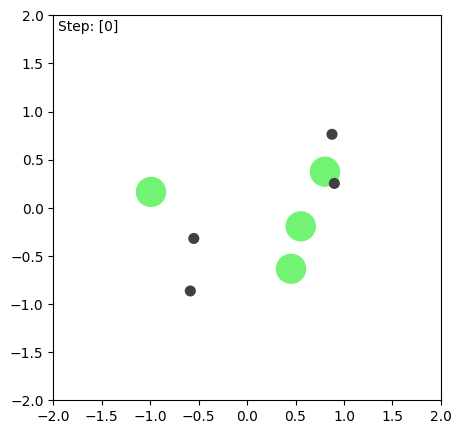

In [17]:
from baselines.Custom.simple_spread_visualizer import MPEVisualizer
env_spread = jaxmarl.make("MPE_simple_spread_v3", **data["ENV_KWARGS"])
viz = MPEVisualizer(env_spread, state_seq)
viz.animate()